# Land-Cover Classification on Operational Satellite Imagery Tutorial
This notebook follows the study in the [project writeup](https://adityakher.com/eoml.html).

We begin with imports and setup:

In [1]:
from pathlib import Path

import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from eoml import indices, inference, models, train, viz
from eoml.data import eurosat, scenes

os.environ["TQDM_DISABLE"] = "1"

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

ARTIFACTS = Path("../artifacts")
ARTIFACTS.mkdir(exist_ok=True)
CHECKPOINT = ARTIFACTS / "eurosat_resnet18.pth"

Using device: cuda


EuroSAT is ~27,000 64×64 pixel chips cut from Sentinel-2 L1C scenes, 13 spectral bands each, labeled with one of 10 land-cover classes; [torchgeo](https://github.com/microsoft/torchgeo) downloads it on first use. We load the dataset splits and their dataloaders:

In [2]:
datasets = eurosat.get_datasets()
dataloaders = eurosat.get_dataloaders(datasets)
{split: len(ds) for split, ds in datasets.items()}

{'train': 16200, 'val': 5400, 'test': 5400}

A few sample training chips:

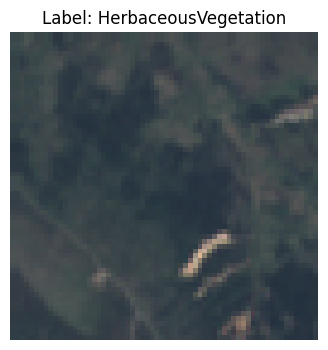

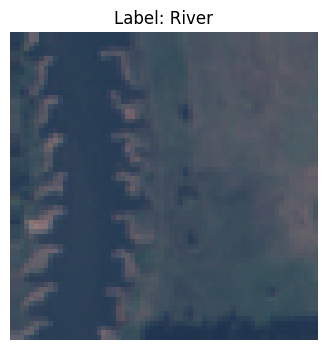

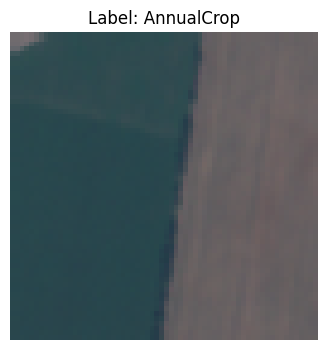

In [3]:
for i in torch.randint(len(datasets["train"]), (3,)):
    sample = datasets["train"][i]
    datasets["train"].plot(sample)

Two transforms from `eoml.data.eurosat`: `get_preprocess()` applies `Normalize(0, 10000)`, scaling raw Sentinel-2 digital numbers to roughly [0, 1] — reused unchanged at inference so the model always sees identical inputs — and `get_augment()` adds training-only flips:

In [4]:
preprocess = eurosat.get_preprocess().to(device)
augment = eurosat.get_augment().to(device)

The classifier is a ResNet-18 with self-supervised MoCo weights pretrained on Sentinel-2 imagery (via torchgeo) plus a fresh 10-class head. Three epochs of fine-tuning reach ~95% test accuracy:

In [5]:
model = models.create_classifier()
train.fit(model, dataloaders, device, epochs=3, preprocess=preprocess, augment=augment);

Epoch 0: loss=486.03, val accuracy=79%
Epoch 1: loss=227.92, val accuracy=92%
Epoch 2: loss=91.66, val accuracy=95%


Evaluate on the held-out test split and save the checkpoint:

In [6]:
test_acc = train.evaluate(model, dataloaders["test"], device, preprocess)
print(f"Test accuracy: {test_acc:.1%}")

models.save_classifier(model, CHECKPOINT)
print(f"Saved checkpoint to {CHECKPOINT}")

Test accuracy: 94.4%
Saved checkpoint to ..\artifacts\eurosat_resnet18.pth


The confusion matrix shows which classes get mixed up — typically the vegetation-adjacent ones:

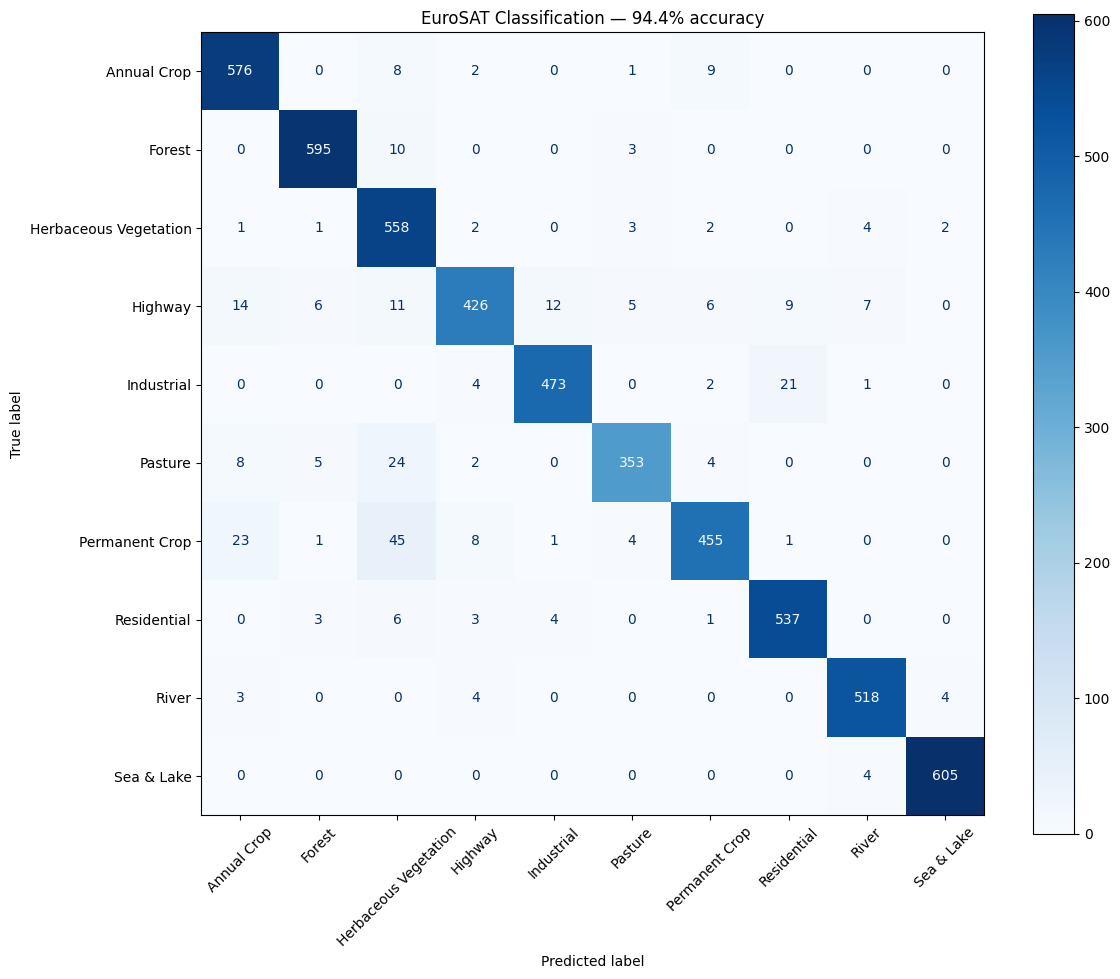

In [7]:
y_true, y_pred = train.predict(model, dataloaders["test"], device, preprocess)
viz.plot_confusion_matrix(y_true, y_pred);

Grad-CAM overlays show which pixels drove each prediction:

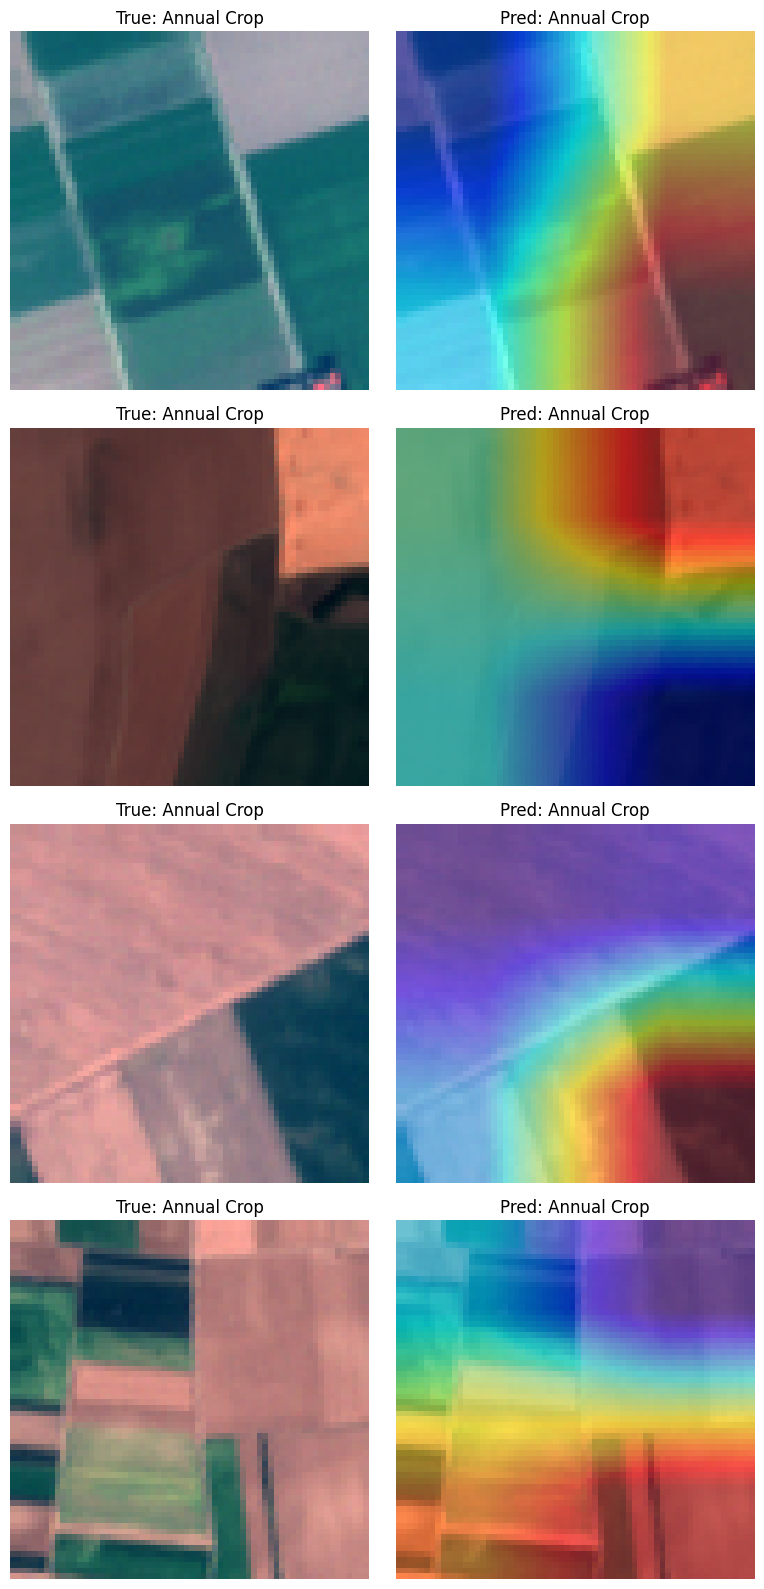

In [8]:
batch = next(iter(dataloaders["test"]))
viz.plot_gradcam_grid(model, batch["image"], batch["label"], device=device, n=4, preprocess=preprocess);

`eoml.data.scenes` searches the [Planetary Computer](https://planetarycomputer.microsoft.com) STAC catalog for Sentinel-2 L2A scenes and loads any bounding box as a single `(band, y, x)` DataArray, every band resampled onto B04's 10 m grid. It ranks results by bounding-box coverage then cloud cover, and subtracts the +1000 DN radiometric offset that post-2022 L2A products carry so values match the EuroSAT scale. We use an agricultural stretch of California's Central Valley:

In [9]:
bbox = [-120.5, 36.6, -120.35, 36.7]  # (west, south, east, north), ~13 x 11 km
items = scenes.search_scenes(bbox, "2024-06-01/2024-06-30", max_cloud_cover=20)
print(f"Found {len(items)} scenes")

item = items[0]  # best bbox coverage, then least cloudy
print(f"Using {item.id} (cloud cover {item.properties['eo:cloud_cover']:.1f}%, "
      f"covers {scenes.bbox_coverage(item, bbox):.0%} of bbox)")

Found 16 scenes
Using S2A_MSIL2A_20240629T183921_R070_T10SGF_20240630T032638 (cloud cover 0.0%, covers 100% of bbox)


Load and stack the bands over the bounding box:

In [10]:
scene = scenes.load_scene(item, bbox=bbox)
print(f"Scene: {scene.shape} (band, y, x), CRS: {scene.rio.crs}")

Scene: (12, 1146, 1372) (band, y, x), CRS: EPSG:32610


True-color composite:

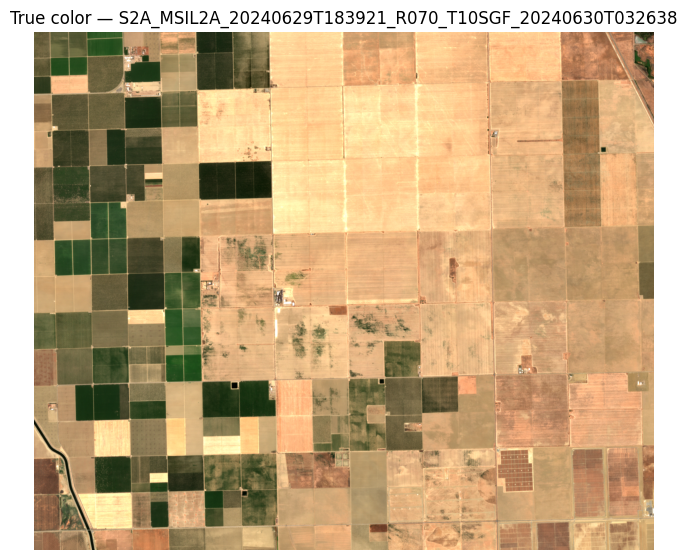

In [11]:
rgb = scene.sel(band=["B04", "B03", "B02"]).values.transpose(1, 2, 0)
rgb = np.clip(rgb / 3000, 0, 1)  # simple contrast stretch

plt.figure(figsize=(8, 7))
plt.imshow(rgb)
plt.axis("off")
plt.title(f"True color — {item.id}");

`classify_scene` is the bridge between the two halves of the framework. It reorders the scene's bands to the EuroSAT layout (zero-filling the absent cirrus band B10), applies the same `Normalize(0, 10000)`, tiles the scene into 64×64 chips, classifies each, and reassembles the predictions into a class map on the scene's grid — one output pixel per 640 m chip. We also return each chip's confidence (max softmax probability) for use below:

Class map: (17, 21) chips


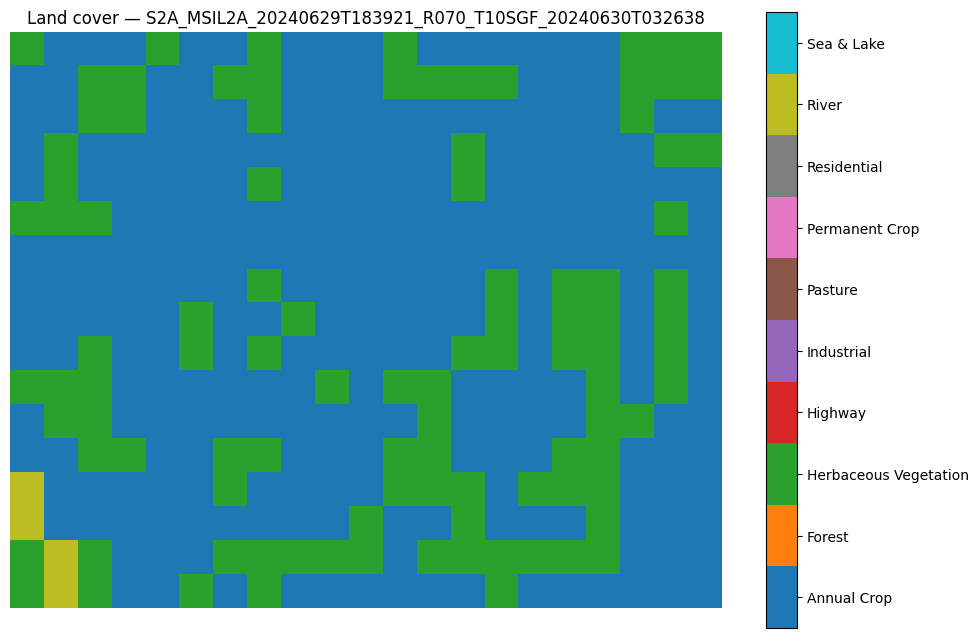

In [12]:
classifier = models.load_classifier(CHECKPOINT, device)
class_map, confidence = inference.classify_scene(
    classifier, scene, device, return_confidence=True
)
print(f"Class map: {class_map.shape} chips")

viz.plot_class_map(class_map, title=f"Land cover — {item.id}");

NDVI = (NIR − Red) / (NIR + Red) uses bands B08 and B04, already present in the loaded scene, so it reuses the same data with no second download:

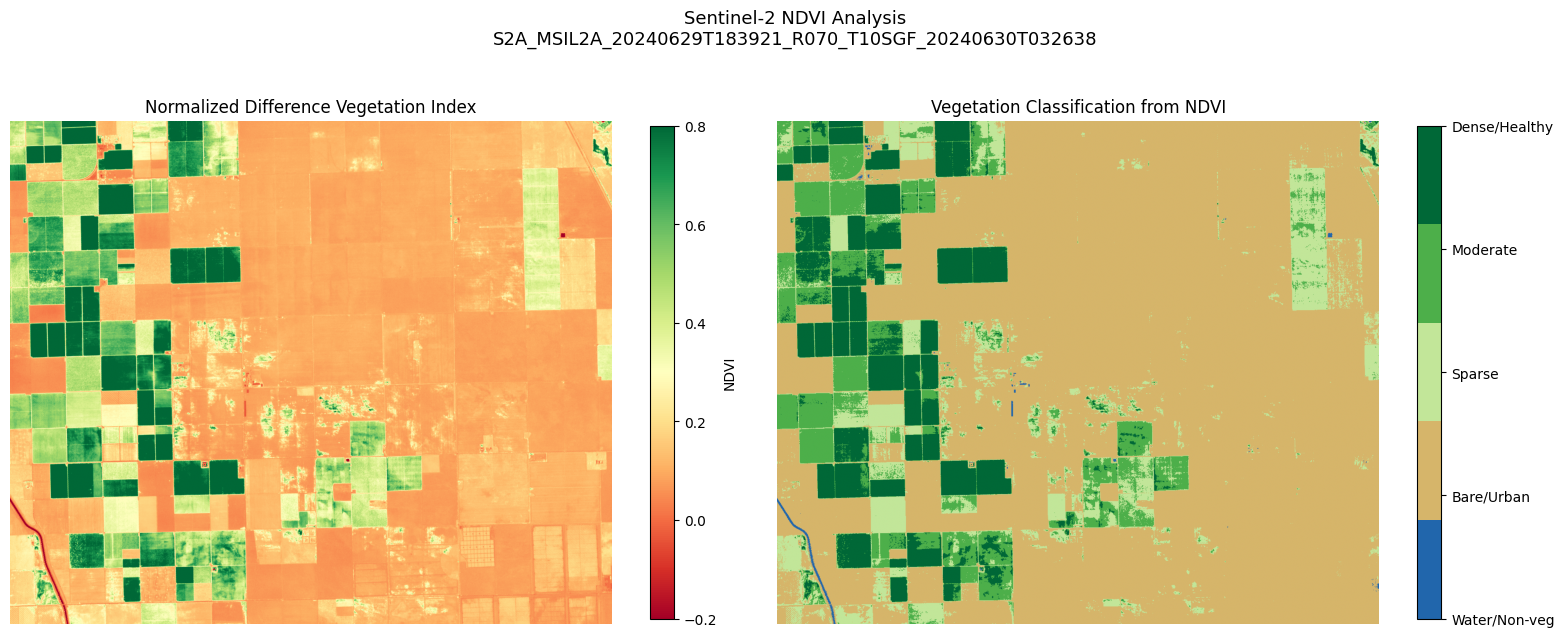

In [13]:
ndvi_da = indices.ndvi(scene)
veg_classes = indices.classify_ndvi(ndvi_da)

viz.plot_ndvi_analysis(ndvi_da, veg_classes, title=f"Sentinel-2 NDVI Analysis\n{item.id}");

To compare the learned labels against NDVI on a common footprint, `inference.chip_stats` aggregates the 10-m NDVI onto the classifier's 640-m chip grid (verified to reproduce its tiling exactly), giving each chip a mean NDVI and a within-chip σ. We group these, and each class's mean confidence, by predicted class:

class                   chips  NDVI mean  within-chip σ  mean MSP
Annual Crop               252     +0.215          0.102     0.425
Herbaceous Vegetation     101     +0.282          0.091     0.375
River                       4     +0.148          0.175     0.436


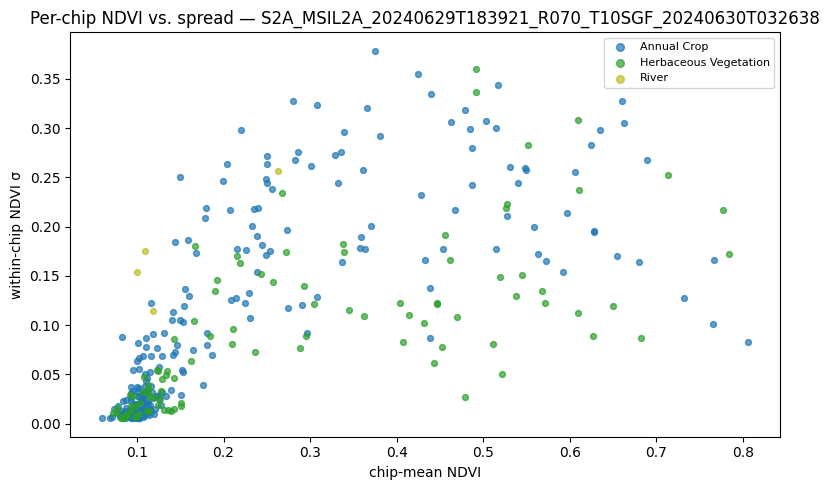

In [14]:
ndvi_mean, ndvi_std = inference.chip_stats(ndvi_da, class_map)

print(f"{'class':22s} {'chips':>6s} {'NDVI mean':>10s} {'within-chip σ':>14s} {'mean MSP':>9s}")
for idx in np.unique(class_map.values):
    m = class_map.values == idx
    print(f"{eurosat.CLASS_NAMES[idx]:22s} {int(m.sum()):6d} "
          f"{ndvi_mean.values[m].mean():+10.3f} {ndvi_std.values[m].mean():14.3f} "
          f"{confidence.values[m].mean():9.3f}")

viz.plot_ndvi_class_scatter(
    class_map, ndvi_mean, ndvi_std,
    title=f"Per-chip NDVI vs. spread — {item.id}",
);

The two vegetation classes overlap in mean NDVI with no clustering in the scatter; within-chip σ separates only River, from water/land edges. The greenness structure NDVI resolves — active versus fallow fields — lies within the dominant Annual Crop class rather than between the labels. All three classes sit at low confidence (mean MSP ≈ 0.38–0.44), far below the near-1.0 the model reaches on EuroSAT test.

`classify_scene` returned that confidence — the per-chip max softmax probability (MSP), a standard out-of-distribution signal. We compare its distribution on this scene against the EuroSAT test set:

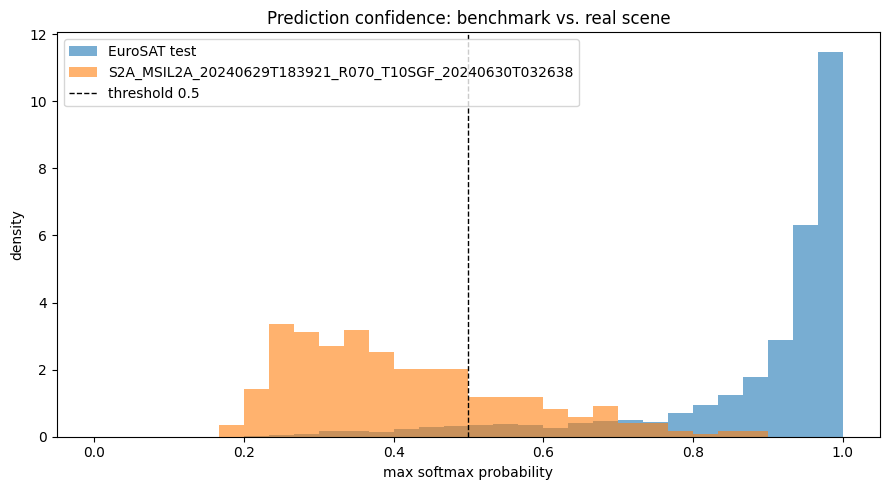

In [15]:
_, _, eurosat_conf = train.predict(
    model, dataloaders["test"], device, preprocess, return_confidence=True
)

viz.plot_confidence_histogram(
    eurosat_conf, confidence, threshold=0.5,
    reference_label="EuroSAT test", scene_label=item.id,
);

The same 0.5 threshold drawn back onto the map:

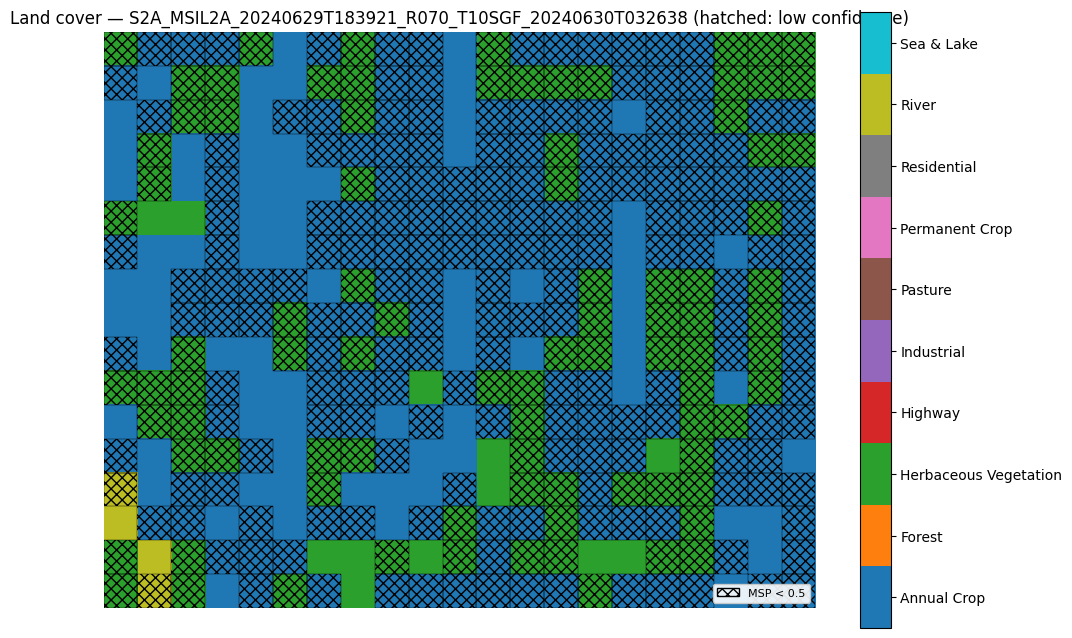

In [16]:
viz.plot_class_map(
    class_map, confidence=confidence, low_conf_threshold=0.5,
    title=f"Land cover — {item.id}",
);

The scene's MSP peaks near 0.35 with a long tail, while the EuroSAT test set piles up near 1.0; at the 0.5 threshold most of the scene is low-confidence. The higher-confidence chips sit weakly over the active green fields — the same active/fallow split NDVI drew. We measure that association:

Pearson r(chip NDVI, chip MSP) = +0.21


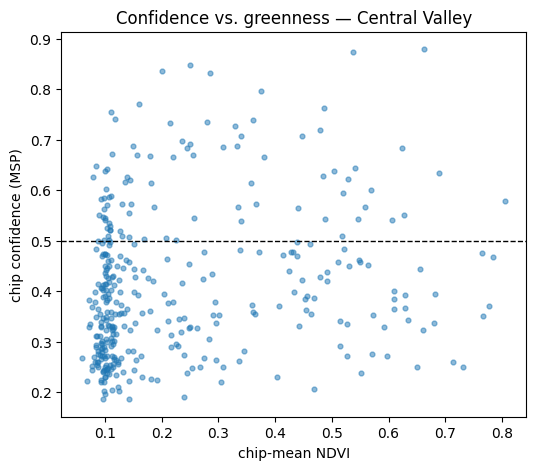

In [17]:
# Does confidence track greenness? Per-chip MSP vs. per-chip mean NDVI.
r = np.corrcoef(ndvi_mean.values.ravel(), confidence.values.ravel())[0, 1]
print(f"Pearson r(chip NDVI, chip MSP) = {r:+.2f}")

plt.figure(figsize=(6, 5))
plt.scatter(ndvi_mean.values.ravel(), confidence.values.ravel(), s=12, alpha=0.5)
plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
plt.xlabel("chip-mean NDVI")
plt.ylabel("chip confidence (MSP)")
plt.title("Confidence vs. greenness — Central Valley");

We repeat the workflow on a contrasting coastal scene near Malibu — open ocean, the urban strip along the Pacific Coast Highway, and Mediterranean chaparral — bundling the search, load, classify, and NDVI steps into one helper function:

In [18]:
def analyze_scene(bbox, datetime, max_cloud_cover=20):
    """Search, load, classify (with confidence), and NDVI a bbox — the steps above."""
    item = scenes.search_scenes(bbox, datetime, max_cloud_cover=max_cloud_cover)[0]
    scene = scenes.load_scene(item, bbox=bbox)
    class_map, confidence = inference.classify_scene(
        classifier, scene, device, return_confidence=True
    )
    return dict(item=item, scene=scene, class_map=class_map,
                confidence=confidence, ndvi=indices.ndvi(scene))

# Santa Monica Mountains + Malibu coastline (west, south, east, north)
malibu = analyze_scene([-118.72, 33.98, -118.58, 34.08], "2024-06-01/2024-09-30",
                       max_cloud_cover=10)
print(f"Using {malibu['item'].id} "
      f"(cloud cover {malibu['item'].properties['eo:cloud_cover']:.1f}%)")

Using S2A_MSIL2A_20240825T182921_R027_T11SLT_20240826T015359 (cloud cover 0.0%)


True color:

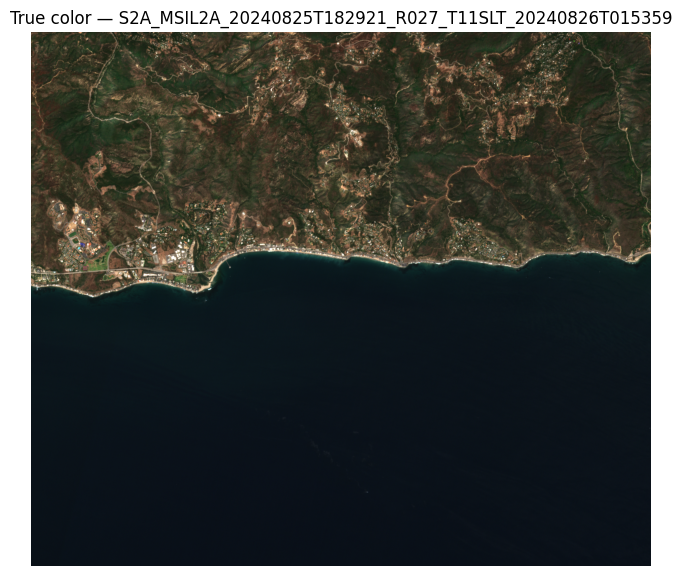

In [19]:
rgb = malibu["scene"].sel(band=["B04", "B03", "B02"]).values.transpose(1, 2, 0)
plt.figure(figsize=(8, 7))
plt.imshow(np.clip(rgb / 3000, 0, 1))
plt.axis("off")
plt.title(f"True color — {malibu['item'].id}");

The classification, with low-confidence chips hatched:

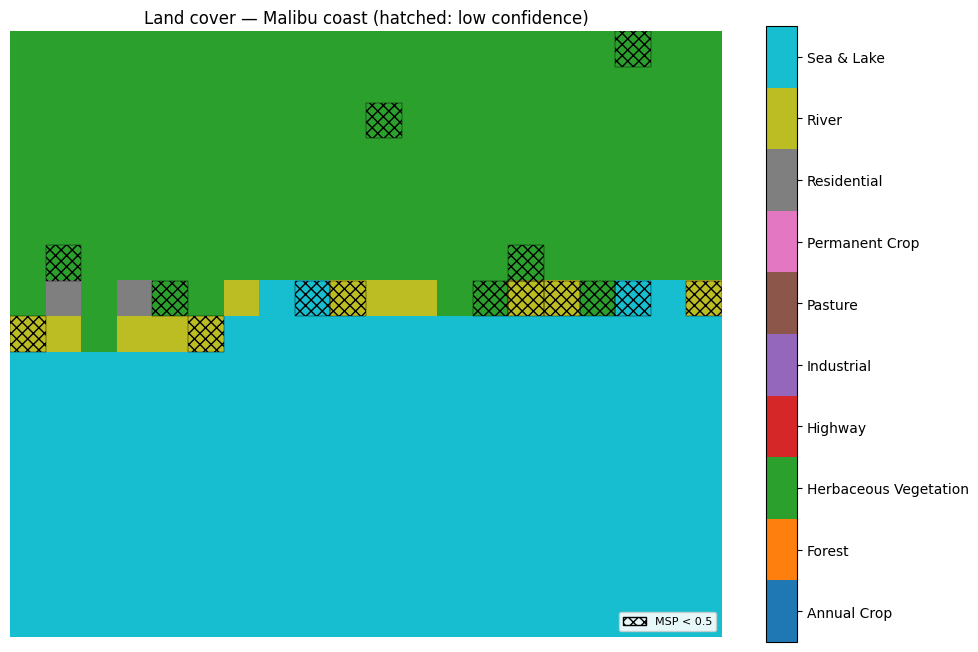

In [20]:
viz.plot_class_map(
    malibu["class_map"], confidence=malibu["confidence"], low_conf_threshold=0.5,
    title=f"Land cover — Malibu coast",
);

Its confidence against the EuroSAT benchmark:

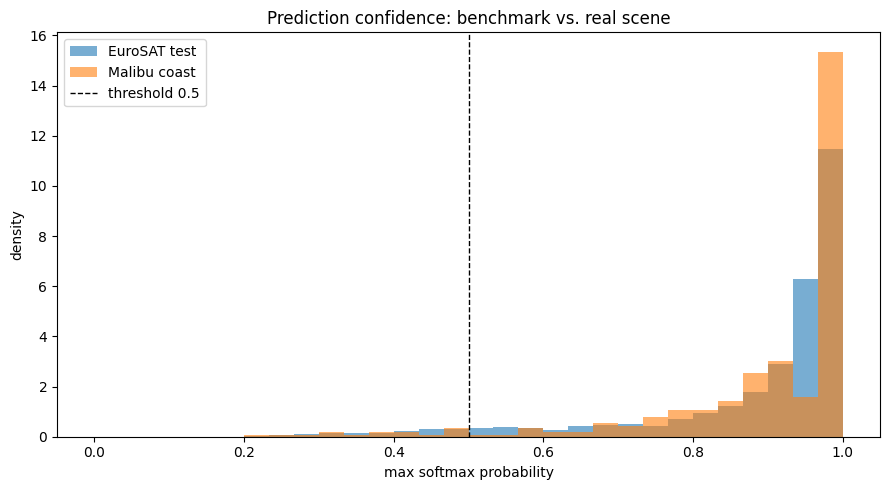

In [21]:
viz.plot_confidence_histogram(
    eurosat_conf, malibu["confidence"], threshold=0.5,
    reference_label="EuroSAT test", scene_label="Malibu coast",
);

Malibu is classified with markedly higher confidence than the Central Valley. Open water goes to Sea & Lake, the chaparral to Herbaceous Vegetation, the coastal strip to Residential and River; confidence falls only along the mixed coastline, and the scene's MSP histogram tracks the EuroSAT test set rather than sitting to its left.

In this tutorial we trained the EuroSAT land-cover classifier, evaluated it with a confusion matrix and Grad-CAM, retrieved Sentinel-2 scenes from the Planetary Computer, and ran both the classifier and NDVI on an agricultural scene in the Central Valley and a coastal scene near Malibu. We compared the two analyses chip by chip and examined the classifier's per-chip confidence against its EuroSAT benchmark, observing that the model is broadly uncertain on the mixed Central Valley scene but near-benchmark on the more homogeneous Malibu scene. For a more detailed discussion of this study, see the [full writeup](https://adityakher.com/eoml.html).